In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Optional: make plots bigger and prettier
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
%matplotlib inline

In [25]:
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

hungarian_path = os.path.join(os.getcwd(), '..', 'Data', 'heart+disease', 'processed.hungarian.data')
hungarian_df = pd.read_csv(hungarian_path, header=None, names=column_names)
switzerland_path = os.path.join(os.getcwd(), '..', 'Data', 'heart+disease', 'processed.switzerland.data')
switzerland_df = pd.read_csv(switzerland_path, header=None, names=column_names)
va_path = os.path.join(os.getcwd(), '..', 'Data', 'heart+disease', 'processed.va.data')
va_df = pd.read_csv(va_path, header=None, names=column_names)

In [ ]:
df = pd.concat([hungarian_df, switzerland_df, va_df], ignore_index=True)

In [29]:
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')

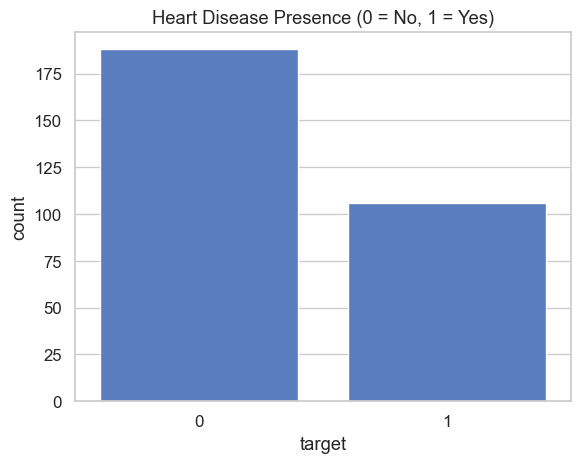

In [30]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Presence (0 = No, 1 = Yes)')
plt.show()

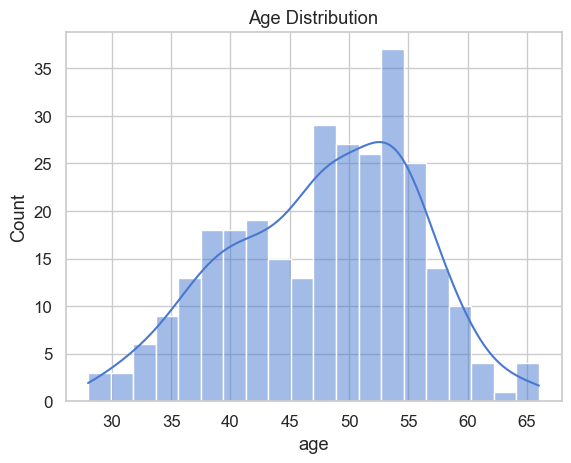

In [31]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.show()

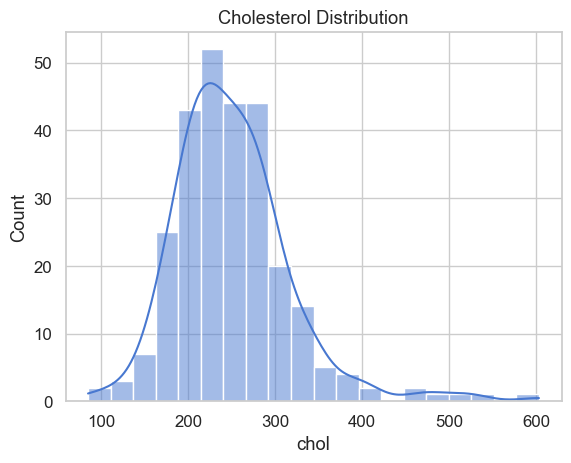

In [32]:
sns.histplot(df['chol'], bins=20, kde=True)
plt.title('Cholesterol Distribution')
plt.show()

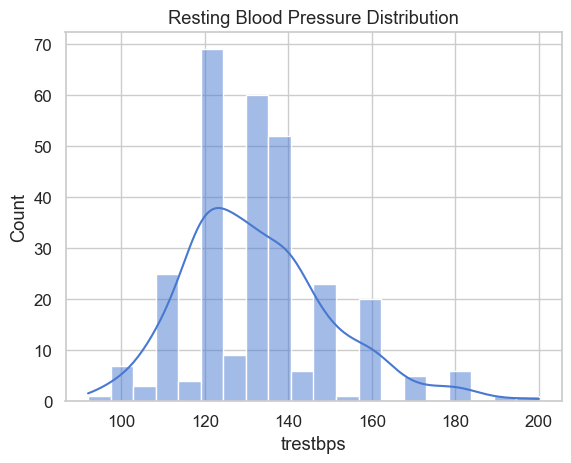

In [33]:
sns.histplot(df['trestbps'], bins=20, kde=True)
plt.title('Resting Blood Pressure Distribution')
plt.show()

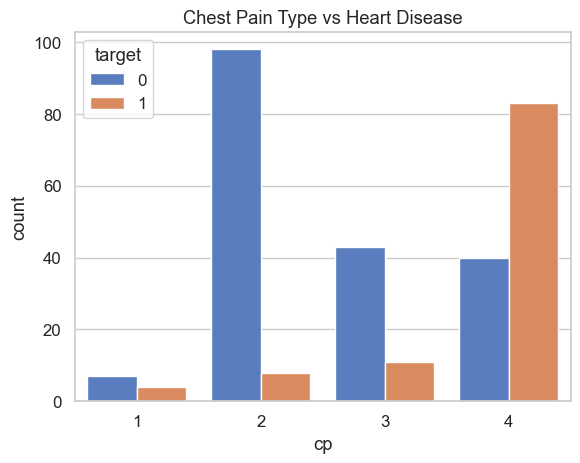

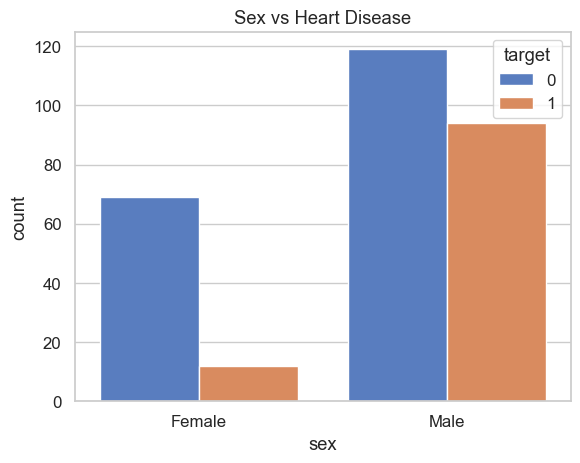

In [34]:
# Chest Pain Type vs Heart Disease
sns.countplot(x='cp', hue='target', data=df)
plt.title('Chest Pain Type vs Heart Disease')
plt.show()

# Sex vs Heart Disease
sns.countplot(x='sex', hue='target', data=df)
plt.title('Sex vs Heart Disease')
plt.xticks([0,1], ['Female', 'Male'])
plt.show()

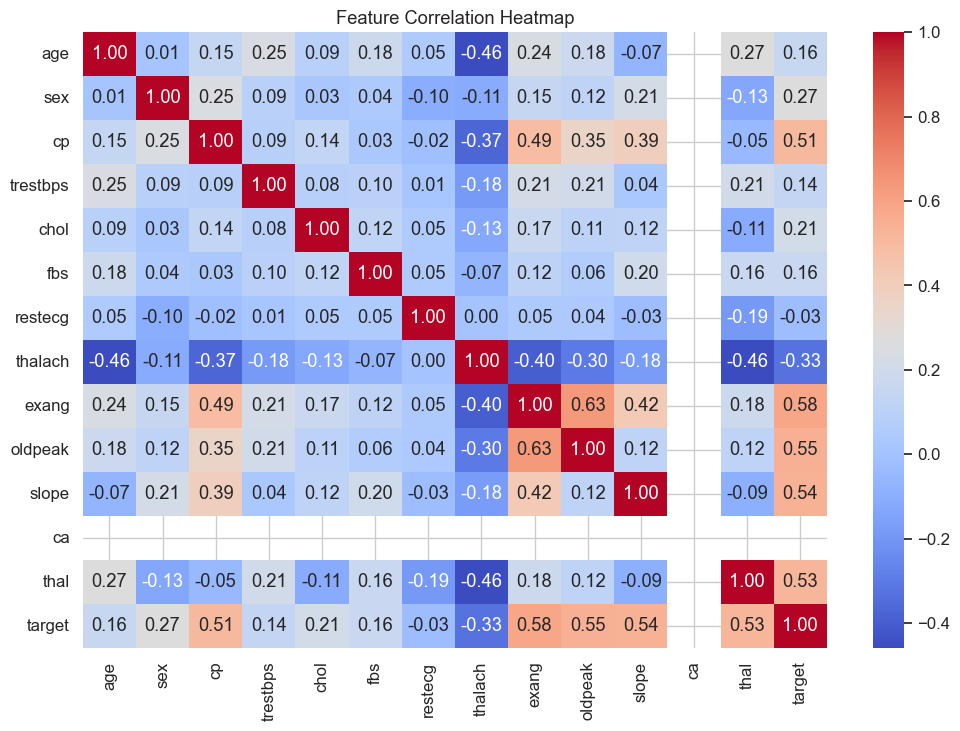

In [35]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

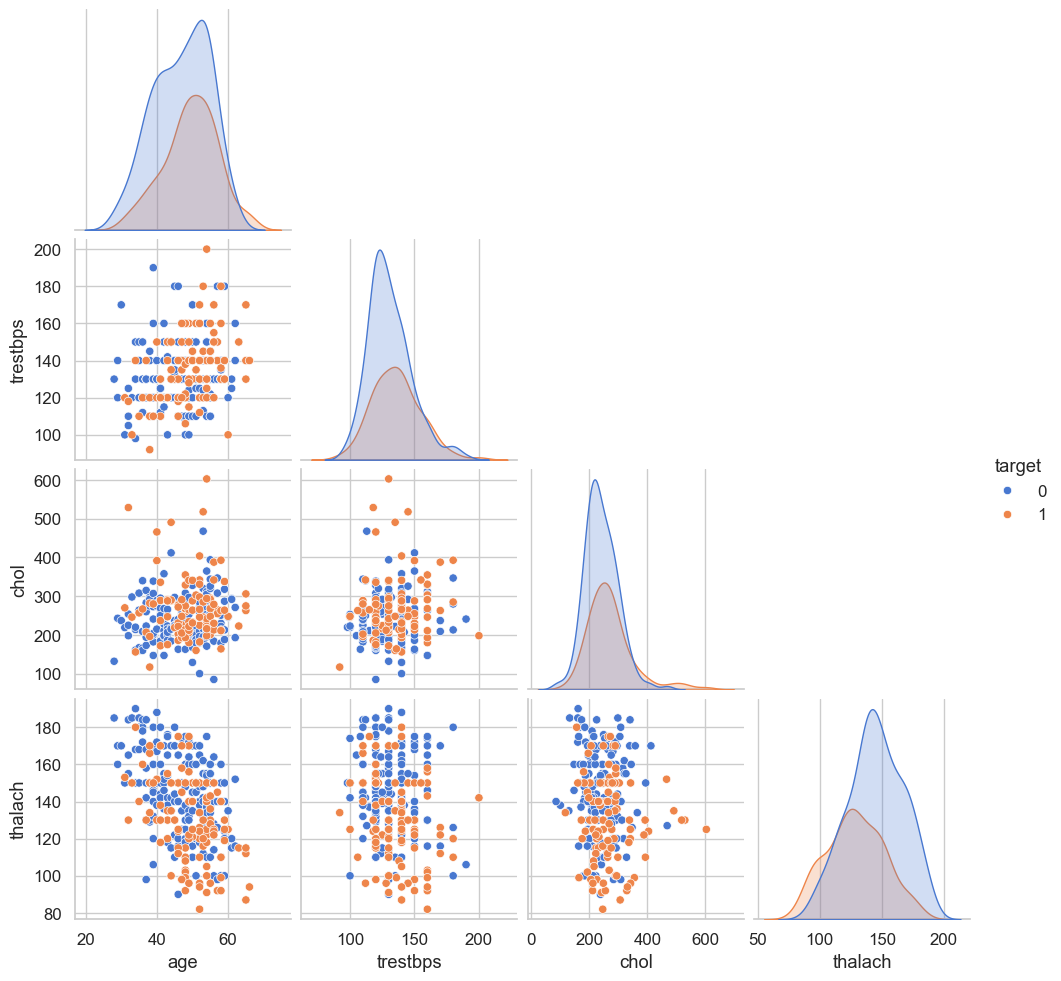

In [36]:
sns.pairplot(df[['age','trestbps','chol','thalach','target']], hue='target', corner=True)
plt.show()